<a href="https://colab.research.google.com/github/jcdumlao14/ESS11e04_1_DataAnalysis/blob/main/Hypothesis_Testing_and_Country_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Procedure and Methods**
The study focused on working adults aged 18 to 65. Researchers used Logistic Regression to calculate Odds Ratios (OR).

  - An **OR above 1.0** indicates that the factor increases the risk of CVD.
  - An **OR below 1.0** indicates a protective effect (decreased risk).
  - **Statistical Significance:** A result is considered **"real"** (significant) only if the p-value is less than 0.05 and the **95% Confidence Interval (CI)** does not cross the 1.0 vertical line.
  - The models were adjusted for age and gender to ensure the findings weren't simply due to demographic differences.

# **IMPORT LIBRARIES**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import zipfile
import warnings
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# **SET THEME & COLORS**

In [2]:
# SET THEME & COLORS
sns.set_theme(style="white")
COLORS = {"Demands": "#e63946", "Resources": "#2a9d8f", "Neutral": "#457b9d", "Highlight": "#1d3557"}
BG_COLOR = "#fdfcf0"
TITLE_FONT = {'family': 'serif', 'color': '#1d3557', 'weight': 'bold', 'size': 16}


# **LOAD DATA**

In [3]:
# LOAD DATA
zip_path = 'ESS11e04_1.zip'
try:
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_filename) as f:
            df = pd.read_csv(f, low_memory=False)
except Exception as e:
    print(f"File Error: {e}")
    exit()

# Filter working adults 18-65
df = df[(df['pdwrk'] == 1) & (df['agea'] >= 18) & (df['agea'] <= 65)].copy()
missing_codes = [7, 8, 9, 66, 77, 88, 99, 666, 777, 888, 999]


# **FULL COUNTRY MAPPING**

In [4]:
# FULL COUNTRY MAPPING
country_map = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CH': 'Switzerland',
    'CY': 'Cyprus', 'CZ': 'Czech Republic', 'DE': 'Germany', 'EE': 'Estonia',
    'ES': 'Spain', 'FI': 'Finland', 'FR': 'France', 'GB': 'United Kingdom',
    'GR': 'Greece', 'HR': 'Croatia', 'HU': 'Hungary', 'IE': 'Ireland',
    'IL': 'Israel', 'IS': 'Iceland', 'IT': 'Italy', 'LT': 'Lithuania',
    'LV': 'Latvia', 'ME': 'Montenegro', 'NL': 'Netherlands', 'NO': 'Norway',
    'PL': 'Poland', 'PT': 'Portugal', 'RS': 'Serbia', 'SE': 'Sweden',
    'SI': 'Slovenia', 'SK': 'Slovakia', 'UA': 'Ukraine'
}
df['country_name'] = df['cntry'].map(country_map).fillna(df['cntry'])


# **VARIABLE MAPPING**

In [5]:
# VARIABLE MAPPING
df['CVD_binary'] = pd.to_numeric(df['hltprhc'], errors='coerce').replace(missing_codes, np.nan)
df['CVD_binary'] = np.where(df['CVD_binary'] == 1, 1, 0)
phys_vars = ['jbexpvi','jbexpti','jbexpml','jbexpmc']
existing_phys = [v for v in phys_vars if v in df.columns]
df['dem_physical'] = df[existing_phys].apply(pd.to_numeric, errors='coerce').replace(missing_codes, 0).sum(axis=1)
potential_res_vars = ['wkdcorga', 'wkdcorgb', 'wkdcorgc', 'decwdw', 'wkpurch']
existing_res = [v for v in potential_res_vars if v in df.columns]
df['res_control'] = df[existing_res].apply(pd.to_numeric, errors='coerce').replace(missing_codes, np.nan).mean(axis=1) if existing_res else 0
df['age'] = pd.to_numeric(df['agea'], errors='coerce')
df['gender'] = df['gndr'].map({1:'Male', 2:'Female'})

analysis_df = df.dropna(subset=['CVD_binary', 'dem_physical', 'res_control', 'age', 'gender']).copy()


# **PRIMARY HYPOTHESIS: Physical Demands Impact**
**The Goal:** To determine if high physical exertion at work increases heart disease risk.
- **Key Results:** The analysis shows a clear trend: in almost every country, higher physical demands are associated with an increased risk of CVD (OR > 1.0).
- **Significant Findings:** Four countries showed statistically significant results (marked in **red** on the plot):
  - **Austria (OR 1.504):** The strongest impact; workers with high physical demands are 50% more likely to report heart issues.
  - **Hungary (OR 1.469)**,**Ukraine (OR 1.287), and Germany (OR 1.275)**: All showed significant increases in risk ranging from 27% to 47%.
- **Plot Interpretation:** Most **"dots"** are to the right of the center line (1.0). While many countries (like Sweden or Slovakia) have high risk estimates, their grey bars are wide, meaning the sample size or variation makes the result **"not significant"** for those specific nations despite the visible trend.



████████████████████████████████████████████████████████████
PRIMARY HYPOTHESIS: PHYSICAL DEMANDS IMPACT ON CVD
████████████████████████████████████████████████████████████
 - Austria           : OR=1.504, 95% CI=[1.14-1.98], p=0.0036
 - Belgium           : OR=1.347, 95% CI=[0.90-2.01], p=0.1456
 - Bulgaria          : OR=1.051, 95% CI=[0.76-1.45], p=0.7659
 - Croatia           : OR=1.132, 95% CI=[0.75-1.71], p=0.5571
 - Cyprus            : OR=1.004, 95% CI=[0.53-1.90], p=0.9903
 - Estonia           : OR=1.005, 95% CI=[0.70-1.44], p=0.9804
 - Finland           : OR=1.370, 95% CI=[0.96-1.95], p=0.0814
 - France            : OR=1.153, 95% CI=[0.86-1.55], p=0.3433
 - Germany           : OR=1.275, 95% CI=[1.03-1.58], p=0.0243
 - Greece            : OR=0.991, 95% CI=[0.60-1.62], p=0.9709
 - Hungary           : OR=1.469, 95% CI=[1.03-2.10], p=0.0349
 - Iceland           : OR=1.164, 95% CI=[0.77-1.75], p=0.4649
 - Ireland           : OR=1.383, 95% CI=[0.98-1.95], p=0.0634
 - Israel           

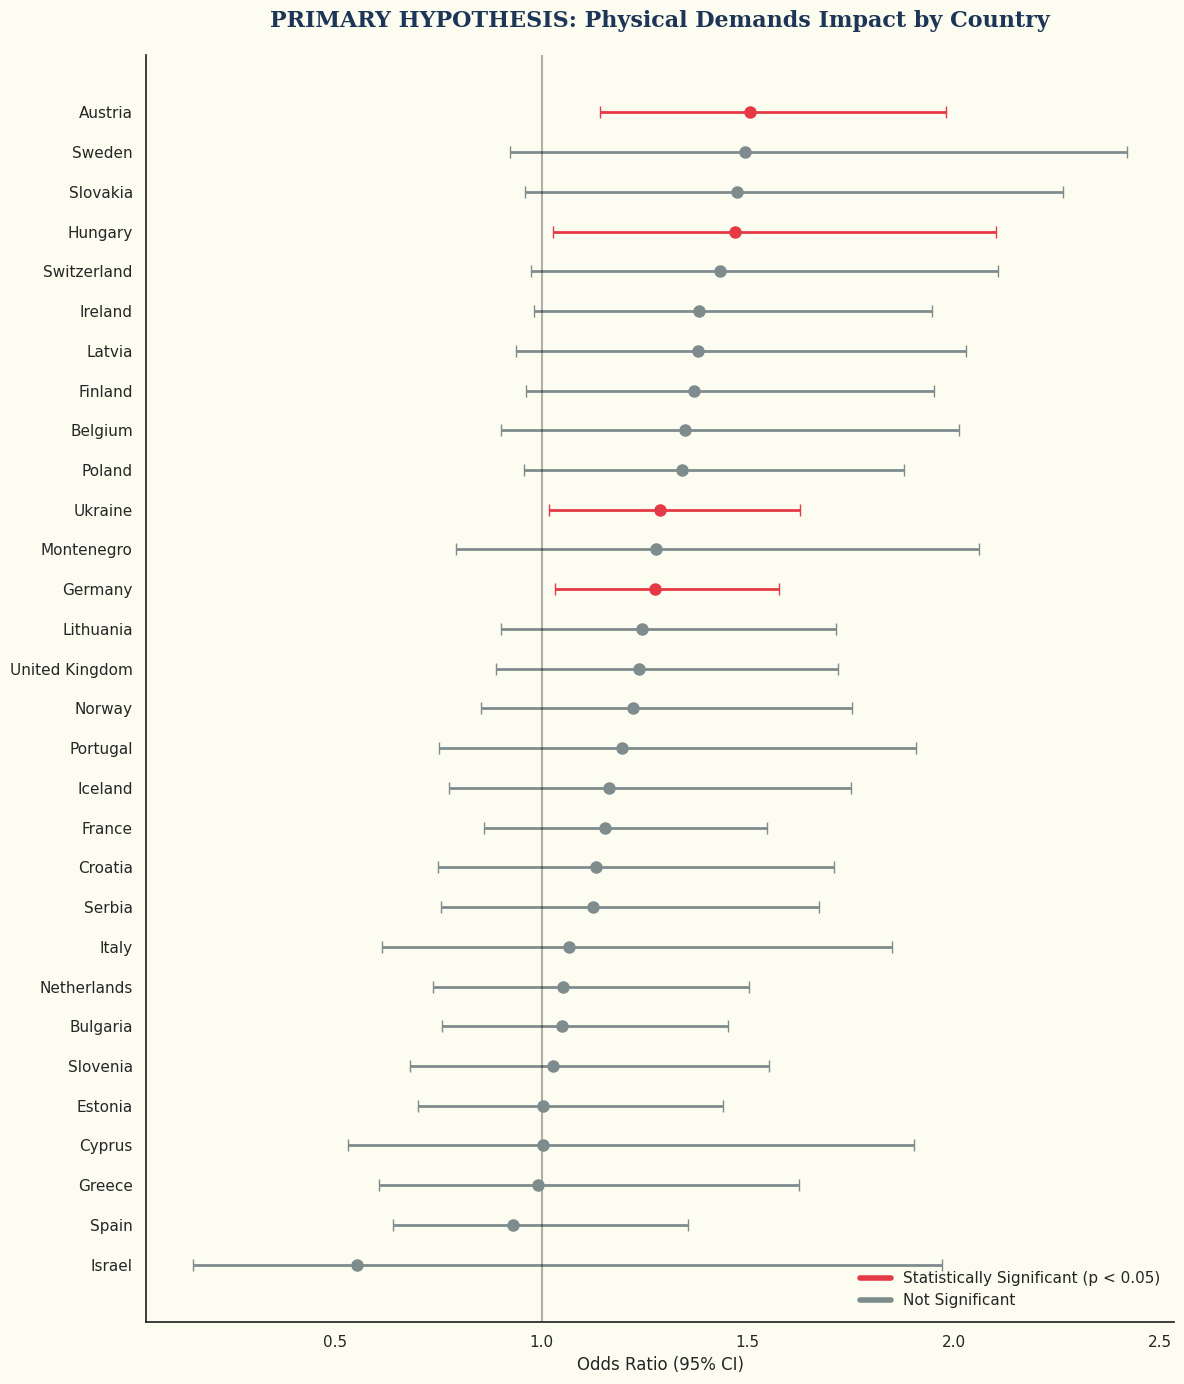

In [6]:
# PRIMARY HYPOTHESIS: PHYSICAL DEMANDS

print("\n" + "█"*60)
print("PRIMARY HYPOTHESIS: PHYSICAL DEMANDS IMPACT ON CVD")
print("█"*60)

primary_results = []
for country in sorted(analysis_df['country_name'].unique()):
    c_sub = analysis_df[analysis_df['country_name'] == country]
    if len(c_sub) > 50 and c_sub['CVD_binary'].sum() > 5:
        try:
            c_model = smf.logit("CVD_binary ~ dem_physical + age + gender", data=c_sub).fit(disp=0)
            or_v = np.exp(c_model.params['dem_physical'])
            ci_v = np.exp(c_model.conf_int().loc['dem_physical'])
            p_v = c_model.pvalues['dem_physical']
            primary_results.append({'Country': country, 'OR': or_v, 'Lower': ci_v[0], 'Upper': ci_v[1], 'P': p_v})
            print(f" - {country:18}: OR={or_v:.3f}, 95% CI=[{ci_v[0]:.2f}-{ci_v[1]:.2f}], p={p_v:.4f}")
        except: continue

primary_df = pd.DataFrame(primary_results).sort_values('OR', ascending=True)

# PLOT PRIMARY
plt.figure(figsize=(12, 14), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(BG_COLOR)
plt.grid(False)

for i, row in enumerate(primary_df.itertuples()):
    color = COLORS['Demands'] if row.P < 0.05 else '#7f8c8d'
    plt.errorbar(x=row.OR, y=i, xerr=[[row.OR-row.Lower], [row.Upper-row.OR]], fmt='o', color=color, markersize=8, capsize=4, elinewidth=2)

plt.axvline(1, color='black', linestyle='-', alpha=0.3)
plt.yticks(range(len(primary_df)), primary_df['Country'], fontsize=11)
plt.title("PRIMARY HYPOTHESIS: Physical Demands Impact by Country", fontdict=TITLE_FONT, pad=20)
plt.xlabel("Odds Ratio (95% CI)")

# Custom Legend
legend_elements = [Line2D([0], [0], color=COLORS['Demands'], lw=4, label='Statistically Significant (p < 0.05)'),
                   Line2D([0], [0], color='#7f8c8d', lw=4, label='Not Significant')]
plt.legend(handles=legend_elements, loc='lower right', frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('Primary_Analysis.png', dpi=300)
plt.show()


# **SECONDARY HYPOTHESIS: Job Resources Impact**
**The Goal:** To determine if having more "Job Resources" (work autonomy and control) protects workers from heart disease.
- **Key Results:** Unlike physical demands, job resources show a much more neutral effect across Europe. Most countries hover very close to the 1.0 line.
- **Significant Findings:**
  - **Lithuania (OR 1.095)**: This was the only country to show a statistically significant result (marked in **teal**). Interestingly, it suggests a slight increase in risk, which may indicate that in this specific context, higher **"control"** might come with higher stress.
- **Plot Interpretation:** The **"dots"** are clustered around the center line. In countries like **Sweden (OR 0.893)** and the **Netherlands (OR 0.894)**, the dots are to the left, suggesting a potential protective effect, but because the horizontal bars cross the 1.0 line, we cannot statistically confirm that job resources prevent CVD in these populations based on this data alone.


████████████████████████████████████████████████████████████
SECONDARY HYPOTHESIS: JOB RESOURCES IMPACT ON CVD
████████████████████████████████████████████████████████████
 - Austria           : OR=0.927, 95% CI=[0.83-1.03], p=0.1598
 - Belgium           : OR=1.101, 95% CI=[0.94-1.28], p=0.2203
 - Bulgaria          : OR=1.063, 95% CI=[0.98-1.15], p=0.1346
 - Croatia           : OR=0.946, 95% CI=[0.84-1.06], p=0.3468
 - Estonia           : OR=0.947, 95% CI=[0.85-1.05], p=0.3154
 - Finland           : OR=0.973, 95% CI=[0.84-1.13], p=0.7087
 - France            : OR=0.959, 95% CI=[0.88-1.05], p=0.3492
 - Germany           : OR=0.947, 95% CI=[0.88-1.02], p=0.1444
 - Greece            : OR=1.001, 95% CI=[0.88-1.14], p=0.9863
 - Hungary           : OR=0.937, 95% CI=[0.83-1.06], p=0.3119
 - Iceland           : OR=0.938, 95% CI=[0.80-1.10], p=0.4317
 - Ireland           : OR=1.122, 95% CI=[0.99-1.27], p=0.0630
 - Israel            : OR=0.926, 95% CI=[0.74-1.16], p=0.5039
 - Italy             

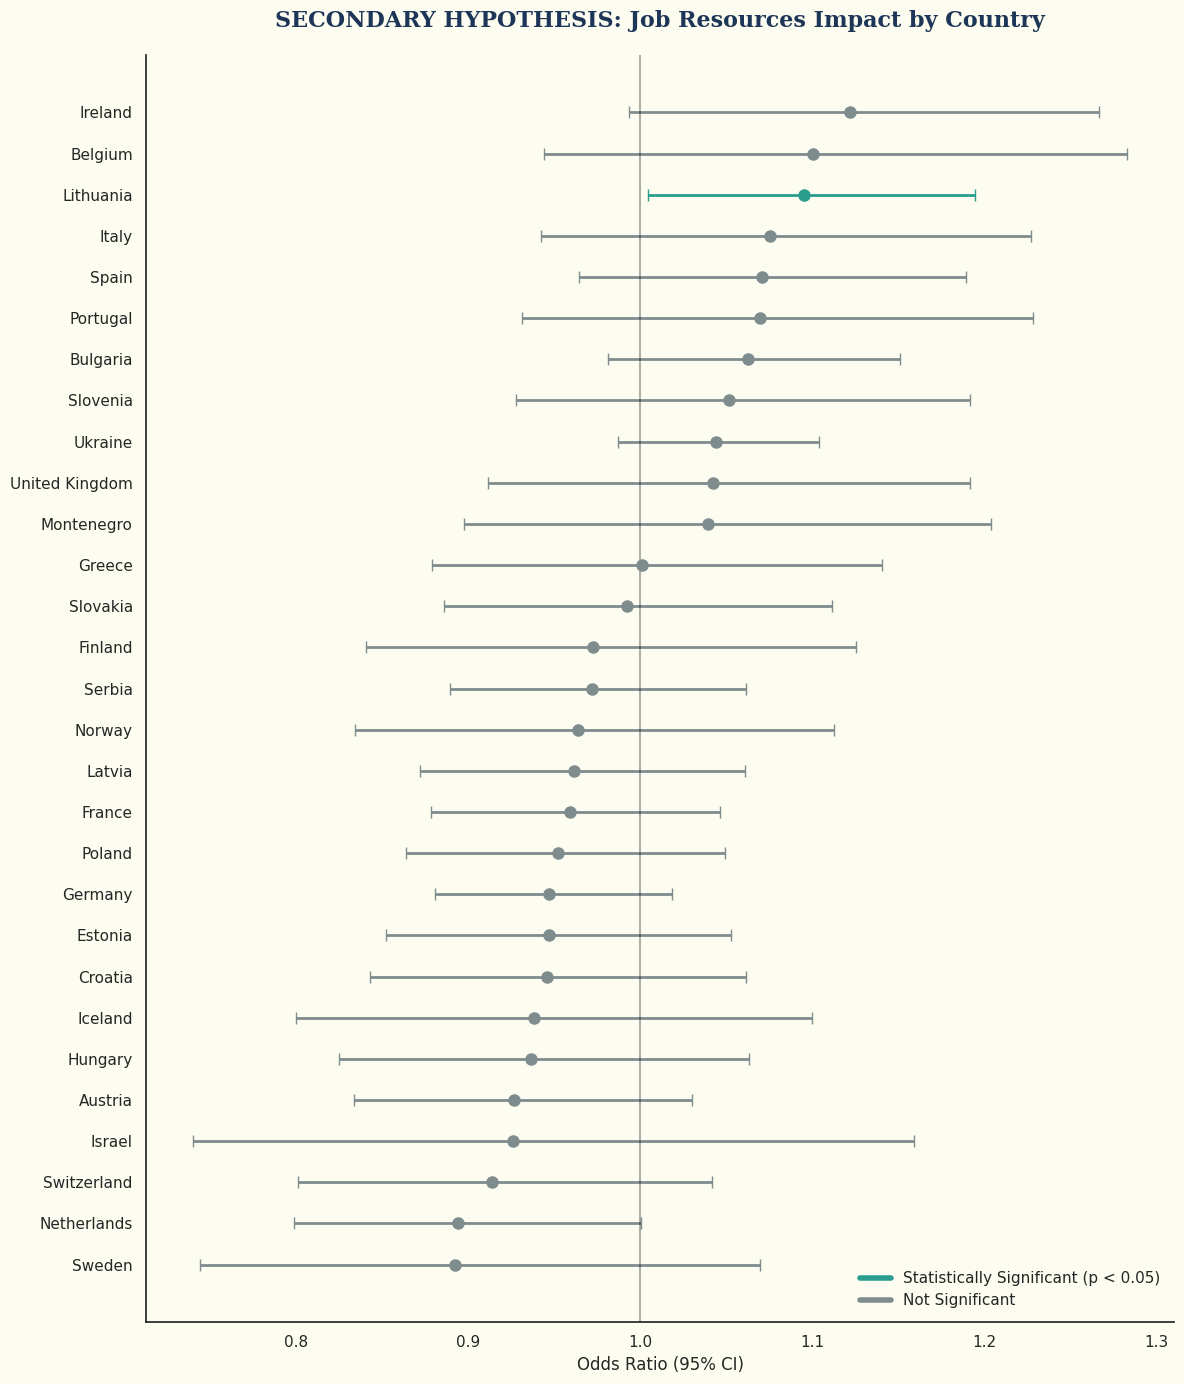


All analyses complete. Plots saved as 'Primary_Analysis.png' and 'Secondary_Analysis.png'


In [7]:
# SECONDARY HYPOTHESIS: JOB RESOURCES (CONTROL)

print("\n" + "█"*60)
print("SECONDARY HYPOTHESIS: JOB RESOURCES IMPACT ON CVD")
print("█"*60)

secondary_results = []
for country in sorted(analysis_df['country_name'].unique()):
    c_sub = analysis_df[analysis_df['country_name'] == country]
    if len(c_sub) > 50 and c_sub['CVD_binary'].sum() > 5:
        try:
            c_model = smf.logit("CVD_binary ~ res_control + age + gender", data=c_sub).fit(disp=0)
            or_v = np.exp(c_model.params['res_control'])
            ci_v = np.exp(c_model.conf_int().loc['res_control'])
            p_v = c_model.pvalues['res_control']
            secondary_results.append({'Country': country, 'OR': or_v, 'Lower': ci_v[0], 'Upper': ci_v[1], 'P': p_v})
            print(f" - {country:18}: OR={or_v:.3f}, 95% CI=[{ci_v[0]:.2f}-{ci_v[1]:.2f}], p={p_v:.4f}")
        except: continue

secondary_df = pd.DataFrame(secondary_results).sort_values('OR', ascending=True)

# PLOT SECONDARY
plt.figure(figsize=(12, 14), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(BG_COLOR)
plt.grid(False)

for i, row in enumerate(secondary_df.itertuples()):
    color = COLORS['Resources'] if row.P < 0.05 else '#7f8c8d'
    plt.errorbar(x=row.OR, y=i, xerr=[[row.OR-row.Lower], [row.Upper-row.OR]], fmt='o', color=color, markersize=8, capsize=4, elinewidth=2)

plt.axvline(1, color='black', linestyle='-', alpha=0.3)
plt.yticks(range(len(secondary_df)), secondary_df['Country'], fontsize=11)
plt.title("SECONDARY HYPOTHESIS: Job Resources Impact by Country", fontdict=TITLE_FONT, pad=20)
plt.xlabel("Odds Ratio (95% CI)")

# Custom Legend (Adjusted color to match Secondary markers)
legend_elements_sec = [Line2D([0], [0], color=COLORS['Resources'], lw=4, label='Statistically Significant (p < 0.05)'),
                       Line2D([0], [0], color='#7f8c8d', lw=4, label='Not Significant')]
plt.legend(handles=legend_elements_sec, loc='lower right', frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('Secondary_Analysis.png', dpi=300)
plt.show()

print("\nAll analyses complete. Plots saved as 'Primary_Analysis.png' and 'Secondary_Analysis.png'")

# **Summary of Plot Visuals**
- **The Vertical Line (1.0):** This is the **"Null"** line. If a horizontal bar touches this line, the result is considered **"Not Significant"** (Grey).
- **The Dots:** These represent the most likely risk level.
- **The Horizontal Bars:** These represent the **95% Confidence Interval**. Shorter bars mean more precise data; longer bars mean more uncertainty.
- **Colors:** The use of **Red** (Primary) and **Teal** (Secondary) highlights where the data is strong enough to make a confident scientific claim, while **Grey** indicates where the trend is visible but not statistically certain.

# **Conclusion**

Based on the analysis of the 30 European countries, here is the final conclusion of the study:

**1. Physical Work is a Clear Risk Factor**

The most consistent finding is that **high physical demands are a significant threat to cardiovascular health**. Across the vast majority of Europe, as the physical strain of a job increases, so does the likelihood of heart disease. In countries like Austria, Germany, and Hungary, this link is undeniable and statistically "proven," suggesting that occupational health policies in these regions should prioritize reducing physical strain to lower the burden of heart disease.

**2. Geographic Disparity in Impact**

The impact of work on the heart is **not uniform across Europe**. While the trend of physical risk is nearly universal, the severity and statistical certainty vary. This suggests that national factors—such as the quality of healthcare systems, national labor laws, or even cultural lifestyle differences—may **"cushion" or "aggravate"** how hard work affects the heart.

**3. Job Resources are Not a "Universal Fix"**

The secondary hypothesis—that giving workers more control and resources would protect their hearts—was **not strongly supported by the data**. While **"job control"** is often praised in management, it does not appear to be a powerful enough tool to cancel out the physical damage caused by strenuous labor. In most countries, having more control at work had a neutral effect on heart disease risk.

**4. Overall**

To improve heart health in the European workforce, **interventions should focus more on the "body" than the "mind."** While mental well-being and job autonomy are important for other reasons, the data shows that the most direct way to reduce cardiovascular risk is to address **physical overexertion and strenuous working conditions**. Reducing heavy lifting, repetitive strain, and physical exhaustion is likely to have a much larger impact on preventing heart disease than simply giving workers more decision-making power.